# Titanic — Exploratory Data Analysis (Task 2)

**Input:** `data/titanic_clean.csv` — the output of Task 1 (891 rows, 0 missing values).
**Goal:** analyze the prepared dataset, compute summary statistics, visualize distributions and relationships, and extract insights that could influence a model or a decision.

Target variable: `Survived` (1 = survived, 0 = did not).


In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 12, "axes.titleweight": "bold"})
FIG = "../reports/figures"
os.makedirs(FIG, exist_ok=True)

def save(name):
    plt.tight_layout()
    plt.savefig(f"{FIG}/{name}.png", dpi=150, bbox_inches="tight")
    plt.show()

df = pd.read_csv("../data/titanic_clean.csv")
df["Pclass"] = df["Pclass"].astype("category")
print(df.shape)
df.head()

(891, 14)


,PassengerId,Survived,Pclass,Title,Sex,Age,AgeWasMissing,SibSp,Parch,FamilySize,IsAlone,Fare,Deck,Embarked
0,1,0,3,Mr,male,22.0,False,1,0,2,False,7.2500,Unknown,S
1,2,1,1,Mrs,female,38.0,False,1,0,2,False,71.2833,C,C
2,3,1,3,Miss,female,26.0,False,0,0,1,True,7.9250,Unknown,S
3,4,1,1,Mrs,female,35.0,False,1,0,2,False,53.1000,C,S
4,5,0,3,Mr,male,35.0,False,0,0,1,True,8.0500,Unknown,S


## 1. Dataset overview & summary statistics

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   PassengerId    891 non-null    int64   
 1   Survived       891 non-null    int64   
 2   Pclass         891 non-null    category
 3   Title          891 non-null    str     
 4   Sex            891 non-null    str     
 5   Age            891 non-null    float64 
 6   AgeWasMissing  891 non-null    bool    
 7   SibSp          891 non-null    int64   
 8   Parch          891 non-null    int64   
 9   FamilySize     891 non-null    int64   
 10  IsAlone        891 non-null    bool    
 11  Fare           891 non-null    float64 
 12  Deck           891 non-null    str     
 13  Embarked       891 non-null    str     
dtypes: bool(2), category(1), float64(2), int64(5), str(4)
memory usage: 79.3 KB


In [3]:
df[["Age","SibSp","Parch","FamilySize","Fare"]].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Age,891.0,29.14,13.49,0.42,21.00,26.00,36.75,80.00
SibSp,891.0,0.52,1.10,0.00,0.00,0.00,1.00,8.00
Parch,891.0,0.38,0.81,0.00,0.00,0.00,0.00,6.00
FamilySize,891.0,1.90,1.61,1.00,1.00,1.00,2.00,11.00
Fare,891.0,32.20,49.69,0.00,7.91,14.45,31.00,512.33


In [4]:
print("Overall survival rate:", round(df.Survived.mean()*100, 1), "%")
print("Skewness -> Fare:", round(df.Fare.skew(),2), "| Age:", round(df.Age.skew(),2))
df.select_dtypes(exclude="number").describe().T

Overall survival rate: 38.4 %
Skewness -> Fare: 4.79 | Age: 0.47


,count,unique,top,freq
Pclass,891,3,3,491
Title,891,5,Mr,517
Sex,891,2,male,577
AgeWasMissing,891,2,False,714
IsAlone,891,2,True,537
Deck,891,9,Unknown,687
Embarked,891,3,S,646


**Reading the numbers:** only ~38% of passengers survived, so the classes are mildly imbalanced. `Fare` is extremely right-skewed (skew ≈ 4.8; median £14.5 vs. mean £32.2, max £512) while `Age` is close to symmetric (skew ≈ 0.5).

## 2. Target balance & numeric distributions

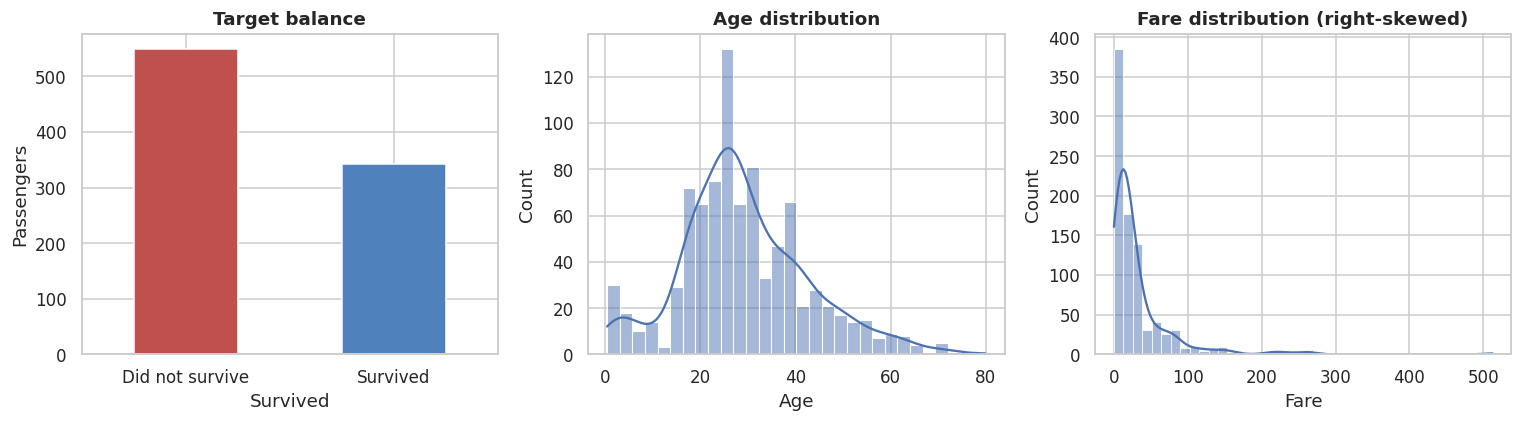

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
df.Survived.map({0:"Did not survive",1:"Survived"}).value_counts().plot.bar(ax=ax[0], color=["#c0504d","#4f81bd"], rot=0)
ax[0].set_title("Target balance"); ax[0].set_ylabel("Passengers")
sns.histplot(df.Age, bins=30, kde=True, ax=ax[1]); ax[1].set_title("Age distribution")
sns.histplot(df.Fare, bins=40, kde=True, ax=ax[2]); ax[2].set_title("Fare distribution (right-skewed)")
save("01_target_age_fare_distributions")

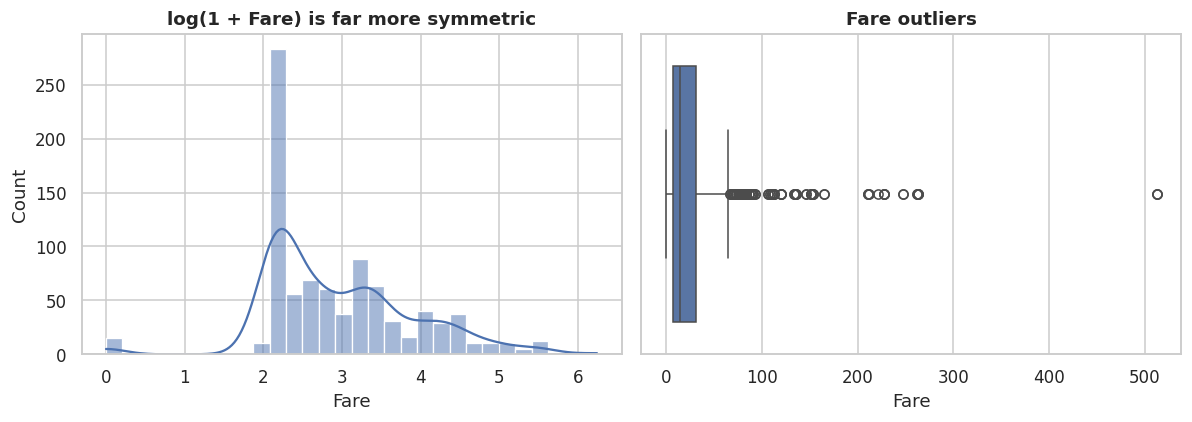

Fare outliers by 1.5*IQR rule: 116 passengers


In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
sns.histplot(np.log1p(df.Fare), bins=30, kde=True, ax=ax[0]); ax[0].set_title("log(1 + Fare) is far more symmetric")
sns.boxplot(x=df.Fare, ax=ax[1]); ax[1].set_title("Fare outliers")
save("02_fare_log_and_outliers")
q1,q3 = df.Fare.quantile([.25,.75]); iqr=q3-q1
print("Fare outliers by 1.5*IQR rule:", int((df.Fare > q3+1.5*iqr).sum()), "passengers")

## 3. Survival by categorical features

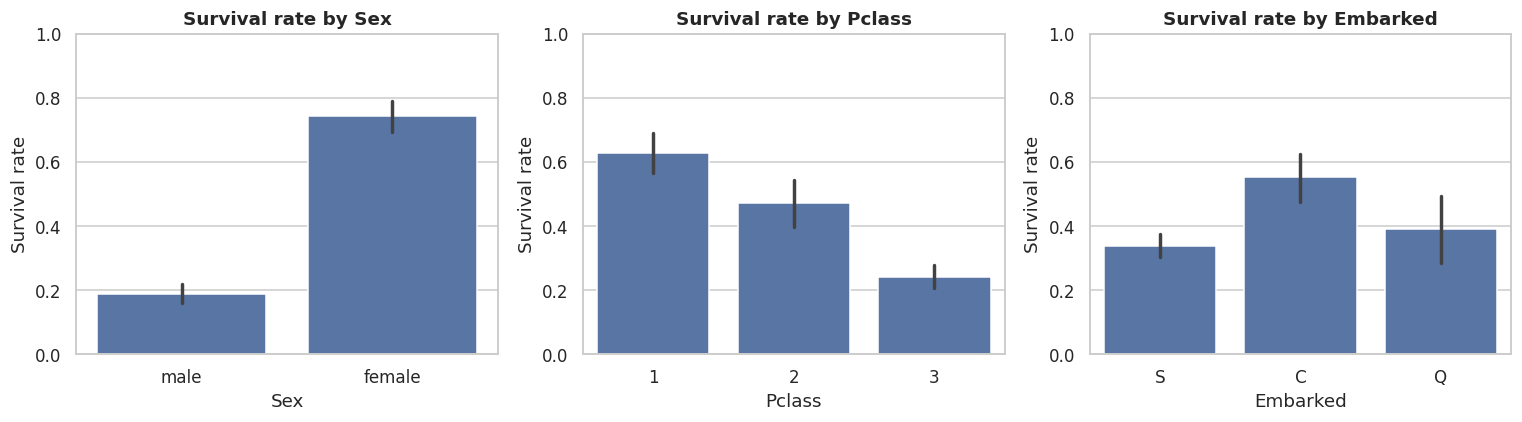

Sex
female    0.742
male      0.189
Name: Survived, dtype: float64 

Pclass
1    0.630
2    0.473
3    0.242
Name: Survived, dtype: float64 

Embarked
C    0.554
Q    0.390
S    0.339
Name: Survived, dtype: float64


In [7]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
for a, col in zip(ax, ["Sex","Pclass","Embarked"]):
    sns.barplot(data=df, x=col, y="Survived", errorbar=("ci",95), ax=a)
    a.set_title(f"Survival rate by {col}"); a.set_ylim(0,1); a.set_ylabel("Survival rate")
save("03_survival_by_sex_class_port")
print(df.groupby("Sex").Survived.mean().round(3), "\n")
print(df.groupby("Pclass", observed=True).Survived.mean().round(3), "\n")
print(df.groupby("Embarked").Survived.mean().round(3))

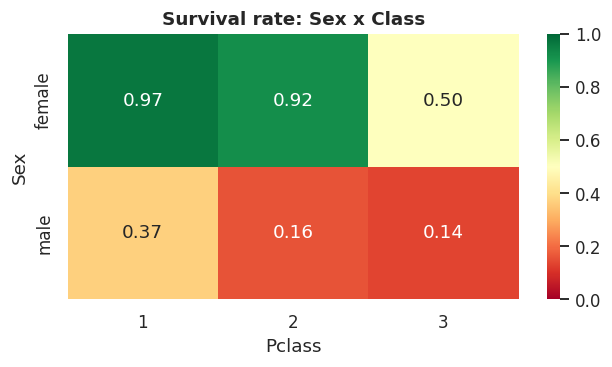

In [8]:
pivot = df.pivot_table(index="Sex", columns="Pclass", values="Survived", aggfunc="mean", observed=True)
plt.figure(figsize=(6,3.5))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1)
plt.title("Survival rate: Sex x Class")
save("04_heatmap_sex_class")

## 4. Age, fare and family effects

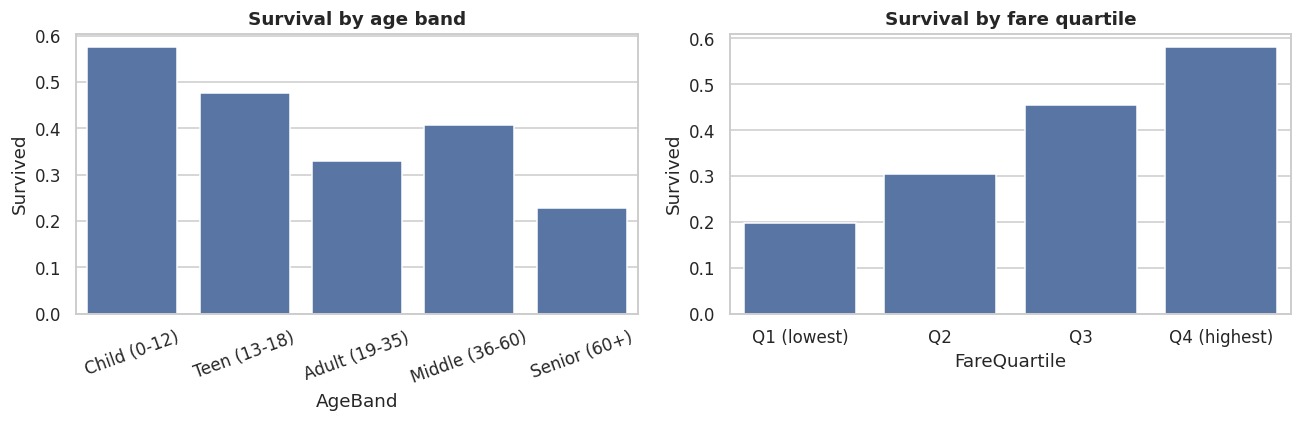

                 mean  count
AgeBand                     
Child (0-12)    0.575     73
Teen (13-18)    0.476    103
Adult (19-35)   0.330    469
Middle (36-60)  0.406    224
Senior (60+)    0.227     22


In [9]:
df["AgeBand"] = pd.cut(df.Age, [0,12,18,35,60,100], labels=["Child (0-12)","Teen (13-18)","Adult (19-35)","Middle (36-60)","Senior (60+)"])
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=df, x="AgeBand", y="Survived", errorbar=None, ax=ax[0]); ax[0].set_title("Survival by age band"); ax[0].tick_params(axis="x", rotation=20)
df["FareQuartile"] = pd.qcut(df.Fare, 4, labels=["Q1 (lowest)","Q2","Q3","Q4 (highest)"])
sns.barplot(data=df, x="FareQuartile", y="Survived", errorbar=None, ax=ax[1]); ax[1].set_title("Survival by fare quartile")
save("05_survival_by_age_and_fare")
print(df.groupby("AgeBand", observed=True).Survived.agg(["mean","count"]).round(3))

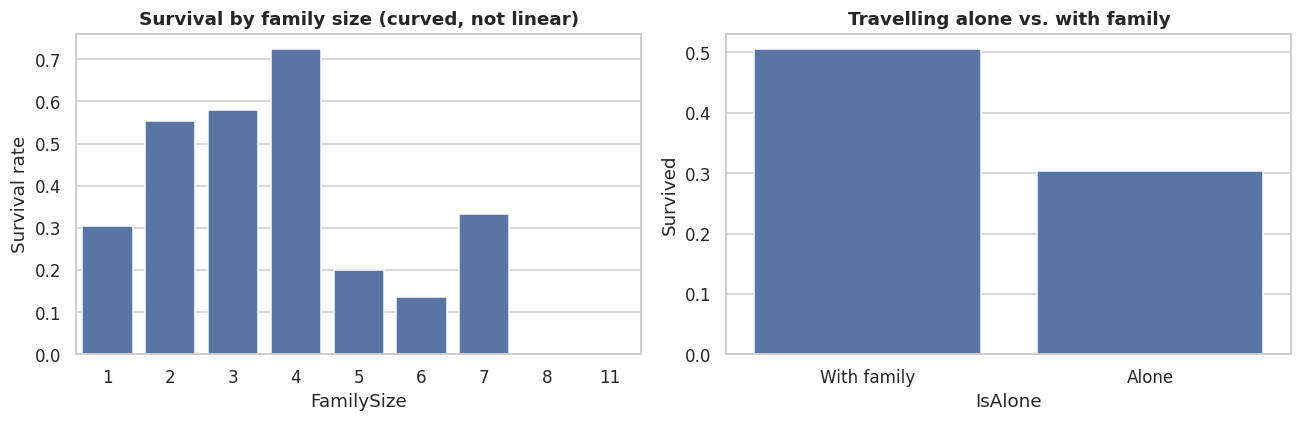

   FamilySize   mean  count
0           1  0.304    537
1           2  0.553    161
2           3  0.578    102
3           4  0.724     29
4           5  0.200     15
5           6  0.136     22
6           7  0.333     12
7           8  0.000      6
8          11  0.000      7


In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
fs = df.groupby("FamilySize").Survived.agg(["mean","count"]).reset_index()
sns.barplot(data=fs, x="FamilySize", y="mean", ax=ax[0]); ax[0].set_title("Survival by family size (curved, not linear)"); ax[0].set_ylabel("Survival rate")
sns.barplot(data=df.assign(IsAlone=df.IsAlone.map({True:"Alone",False:"With family"})), x="IsAlone", y="Survived", errorbar=None, ax=ax[1]); ax[1].set_title("Travelling alone vs. with family")
save("06_family_size_and_alone")
print(fs.round(3))

## 5. Titles, deck, and the imputation flag

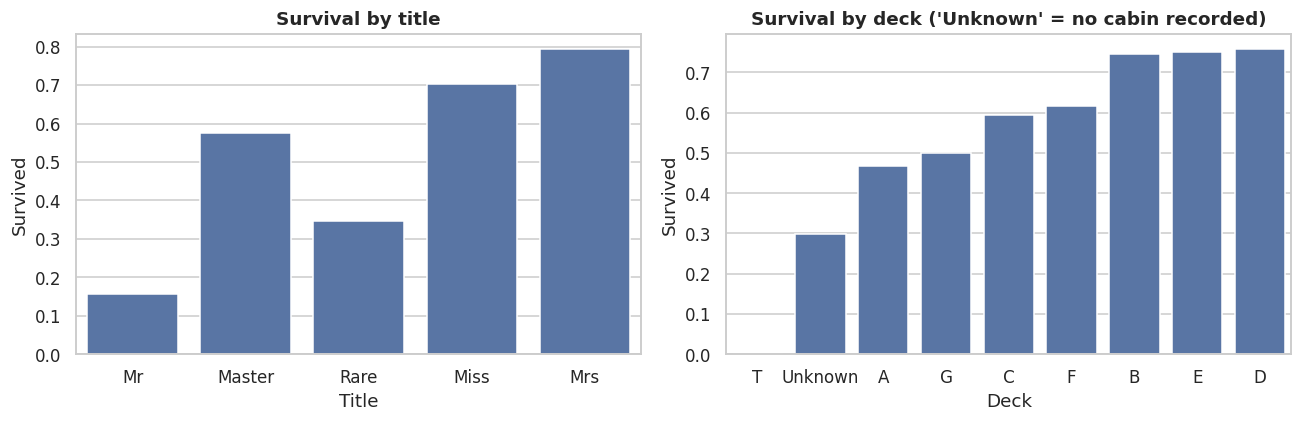

          mean  count
Deck                 
Unknown  0.300    687
C        0.593     59
B        0.745     47
D        0.758     33
E        0.750     32
A        0.467     15
F        0.615     13
G        0.500      4
T        0.000      1


In [11]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.barplot(data=df, x="Title", y="Survived", errorbar=None, order=["Mr","Master","Rare","Miss","Mrs"], ax=ax[0]); ax[0].set_title("Survival by title")
order = df.groupby("Deck").Survived.mean().sort_values().index
sns.barplot(data=df, x="Deck", y="Survived", errorbar=None, order=order, ax=ax[1]); ax[1].set_title("Survival by deck ('Unknown' = no cabin recorded)")
save("07_title_and_deck")
print(df.groupby("Deck").Survived.agg(["mean","count"]).round(3).sort_values("count", ascending=False))

## 6. Correlations

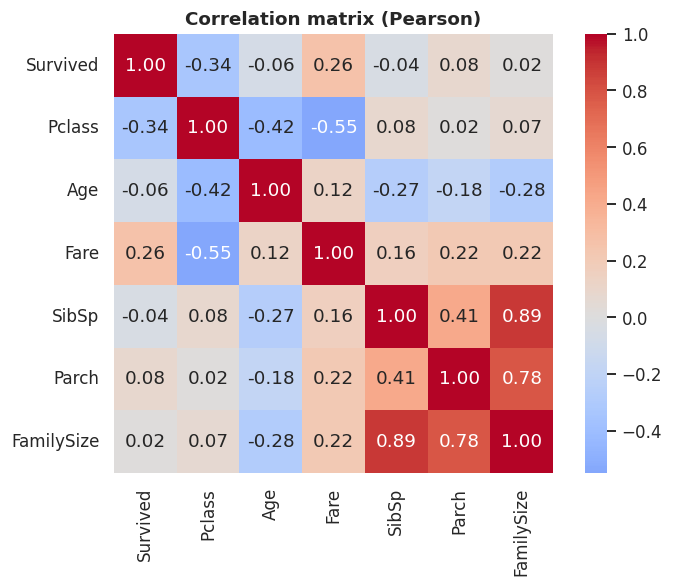

In [12]:
num = df[["Survived","Pclass","Age","Fare","SibSp","Parch","FamilySize"]].copy()
num["Pclass"] = num["Pclass"].astype(int)
plt.figure(figsize=(7,5.5))
sns.heatmap(num.corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation matrix (Pearson)")
save("08_correlation_matrix")

## 7. Statistical tests (is the pattern real or noise?)

In [13]:
def chi(a, b):
    chi2, p, dof, _ = stats.chi2_contingency(pd.crosstab(df[a], df[b]))
    n = len(df); k = min(pd.crosstab(df[a], df[b]).shape) - 1
    return {"feature": a, "chi2": round(chi2,1), "p_value": p, "cramers_v": round(np.sqrt(chi2/(n*k)),3)}

res = pd.DataFrame([chi(c, "Survived") for c in ["Sex","Pclass","Embarked","IsAlone","Deck","Title"]]).sort_values("cramers_v", ascending=False)
res["p_value"] = res.p_value.apply(lambda v: f"{v:.2e}")
display(res)

u = stats.mannwhitneyu(df[df.Survived==1].Fare, df[df.Survived==0].Fare)
print("Fare survivors vs non-survivors (Mann-Whitney U) p =", f"{u.pvalue:.2e}")
print("Median fare -> survived:", df[df.Survived==1].Fare.median().round(2), "| died:", df[df.Survived==0].Fare.median().round(2))
u2 = stats.mannwhitneyu(df[df.Survived==1].Age, df[df.Survived==0].Age)
print("Age survivors vs non-survivors (Mann-Whitney U) p =", f"{u2.pvalue:.3f}")

,feature,chi2,p_value,cramers_v
5,Title,288.1,3.96e-61,0.569
0,Sex,260.7,1.20e-58,0.541
1,Pclass,102.9,4.55e-23,0.340
4,Deck,99.2,6.33e-18,0.334
3,IsAlone,36.0,1.97e-09,0.201
2,Embarked,26.0,2.30e-06,0.171


Fare survivors vs non-survivors (Mann-Whitney U) p = 4.55e-22
Median fare -> survived: 26.0 | died: 10.5
Age survivors vs non-survivors (Mann-Whitney U) p = 0.216


## 8. Data-quality check on Task 1's Age imputation

In [14]:
print(df.groupby("AgeWasMissing").Survived.agg(["mean","count"]).round(3))
print("\nMean age  -> real:", df[~df.AgeWasMissing].Age.mean().round(1), "| imputed:", df[df.AgeWasMissing].Age.mean().round(1))
print("Age std   -> real:", df[~df.AgeWasMissing].Age.std().round(1), "| imputed:", df[df.AgeWasMissing].Age.std().round(1))
print(pd.crosstab(df.AgeWasMissing, df.Pclass, normalize="index").round(2))

                mean  count
AgeWasMissing              
False          0.406    714
True           0.294    177

Mean age  -> real: 29.7 | imputed: 26.9
Age std   -> real: 14.5 | imputed: 7.7
Pclass            1     2     3
AgeWasMissing                  
False          0.26  0.24  0.50
True           0.17  0.06  0.77


## 9. Key insights

**Insight 1 — Sex (and Title, which encodes it) are the strongest predictors.**
Women survived at **74.2%** versus **18.9%** for men (chi-square p ≈ 1e-58, Cramér's V = 0.54; `Title` is marginally higher at 0.57 because it carries sex plus age-group information). *Model impact:* keep `Sex` (or `Title`) as a core feature; any model that ignores it will underperform. *Decision impact:* the historical "women and children first" policy is visible directly in the data.

**Insight 2 — Class matters, and it interacts with sex.**
Survival falls from **63%** (1st) to **47%** (2nd) to **24%** (3rd). The heatmap shows the interaction: 1st/2nd-class women survived at **97% / 92%**, while 3rd-class men survived at only **14%**. *Model impact:* a linear model needs a `Sex x Pclass` interaction term; tree-based models (Random Forest, Gradient Boosting) will find it automatically.

**Insight 3 — `Fare` is heavily skewed and partly redundant with class.**
Skew ≈ **4.8**, with a few fares above £500. Fare correlates with `Pclass` at **-0.55**, and survival rises steadily across fare quartiles (**20% → 30% → 45% → 58%**). *Model impact:* apply `log1p(Fare)` for linear/distance-based models and use quartile bins or trees for robustness; watch for multicollinearity between `Fare` and `Pclass`.

**Insight 4 — Family size has a non-linear (sweet-spot) effect.**
Solo travellers survived at **30%**; families of 2-4 at **55-72%**; families of 5-6 collapsed to **14-20%**, and the largest (8 and 11) had **0%** survival. The overall correlation between `FamilySize` and survival is ~0.02, which would wrongly suggest "no effect". *Model impact:* never feed `FamilySize` as a plain linear feature; bin it (alone / small / large) or use a tree model. This is why the engineered feature from Task 1 is valuable.

**Insight 5 — Title carries more information than Age or Sex alone.**
`Master` (boys) survived at **57.5%** vs **15.7%** for `Mr`; `Mrs` **79.4%**, `Miss` **70.3%**. Age on its own has a weak correlation with survival (**-0.06**; survivor vs. non-survivor age difference is not statistically significant, p ≈ 0.22) and only children (0-12, **57.5%**) stand out clearly. *Model impact:* `Title` captures both age-group and sex signals and also gave a principled basis for imputing missing ages; prefer age bands over raw age.

**Insight 6 — Cabin *availability* is informative, but is a proxy for class (and a leakage warning).**
Passengers with a recorded deck survived at **59-76%** (decks B-E) versus **30%** for `Unknown`. Cabin records exist for **81%** of 1st-class passengers but only **9%** of 2nd and **2%** of 3rd, so this is largely a class effect. *Decision impact:* the "Unknown" bucket was the right call in Task 1 rather than dropping or guessing cabins; but treat it as a proxy and avoid over-interpreting deck.

**Insight 7 — Port of embarkation shows an effect that is probably confounded.**
Cherbourg passengers survived at **55%** versus **34%** for Southampton. **51%** of Cherbourg passengers were 1st class versus **20%** at Southampton, so much of this is likely class, not geography. *Model impact:* low standalone value; test it with and without class before trusting it.

**Insight 8 — Task 1's imputed ages are lower-variance, and missingness itself is a signal.**
Passengers whose age was missing survived at **29%** vs **41%** for those with a known age; **77%** of them were 3rd class (vs. 50% otherwise), and the imputed ages have a much narrower spread (std **7.7** vs **14.5** years). *Model impact:* keep the `AgeWasMissing` flag as a feature, and consider comparing median imputation against model-based imputation as a sensitivity check.

### Summary table
| # | Insight | Recommended modelling action |
|---|---|---|
| 1 | Sex/Title dominate survival | Core features; don't drop |
| 2 | Class x Sex interaction | Interaction terms or tree models |
| 3 | Fare skewed, correlated with class | `log1p(Fare)` + watch multicollinearity |
| 4 | Family size non-linear | Bin into alone / small / large |
| 5 | Title > raw Age | Use Title and age bands |
| 6 | Cabin known = proxy for class | Keep "Unknown" category; interpret carefully |
| 7 | Embarked likely confounded | Validate against class |
| 8 | Missing age is informative | Keep `AgeWasMissing` flag |

### Limitations
This is observational, historical data (891 of ~2,200 people aboard), so these patterns describe correlation within this sample, not causal effects. Some groups are small (e.g. decks A/F/G, family size 7+), so their rates are noisy.
